# A Simple Method to Project Sentinel-2 Reflectance Data onto a HEALPix Grid

In [1]:
import healpy as hp
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# Open a remote Zarr dataset hosted at the given URL using xarray
# Zarr format efficiently stores multidimensional arrays, especially useful for large geospatial datasets
ds = xr.open_zarr('https://data-taos.ifremer.fr/GRID4EARTH/S2A_OPER_MSI_L1B_GR_2APS_20250724T145646_S20250724T112804_D06_N05.11_B02.zarr')

# Display dataset structure and metadata
# This prints a summary including dimensions, coordinates, data variables, and attributes
ds

<xarray.Dataset> Size: 118MB
Dimensions:      (y: 2304, x: 2552)
Coordinates:
    band         int64 8B ...
    spatial_ref  int64 8B ...
  * x            (x) float64 20kB 0.5 1.5 2.5 ... 2.55e+03 2.55e+03 2.552e+03
  * y            (y) float64 18kB 0.5 1.5 2.5 ... 2.302e+03 2.302e+03 2.304e+03
Data variables:
    B02          (y, x) float32 24MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    latitude     (y, x) float64 47MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    longitude    (y, x) float64 47MB dask.array<chunksize=(512, 512), meta=np.ndarray>

In [3]:
# Define HEALPix resolution level (higher value means higher spatial resolution)
level = 19

# Compute the HEALPix pixel indices ("hidx") corresponding to each point defined by longitude and latitude
# "2**level" sets the resolution of the HEALPix grid (higher Nside means smaller pixels)
# ds.longitude.values.flatten() and ds.latitude.values.flatten() are arrays of longitude and latitude in degrees
# "lonlat=True" indicates the input coordinates are in longitude-latitude format (degrees), not theta-phi (radians)
# "nest=True" means the HEALPix indexing uses "nested" ordering rather than "ring" ordering
hidx = hp.ang2pix(2**level,
                  ds.longitude.values.flatten(),
                  ds.latitude.values.flatten(),
                  lonlat=True,
                  nest=True)

# Find the unique HEALPix pixel indices ("h") and also return indices ("ih") 
# which map each original coordinate to its unique pixel index
h, ih = np.unique(hidx, return_inverse=True)

# Convert the unique HEALPix pixel indices ("h") back into their corresponding pixel center coordinates (lon, lat)
# This provides the central longitude and latitude of each unique HEALPix pixel
lon, lat = hp.pix2ang(2**level,
                      h,
                      lonlat=True,
                      nest=True)

In [4]:
# Count how many original points fall into each unique HEALPix pixel
# "ih" maps each point to its pixel; bincount gives the number of occurrences per pixel
image_hit = np.bincount(ih)

# Sum the values of band "B02" from the original dataset for each HEALPix pixel
# "weights" sums the B02 values that fall into each pixel defined by "ih"
image_b02 = np.bincount(ih, weights=ds.B02.values.flatten())

# Compute the mean B02 reflectance value for each HEALPix pixel
# by dividing the sum of B02 values by the number of points (hits) in each pixel
image_b02 /= image_hit

In [5]:
# Let's say B02_interp_array is your (y, x) float32 dask array
ds["B02_interp"] = xr.DataArray(
    data=image_b02[ih].reshape(ds.longitude.values.shape),         # your computed/interpolated values
    dims=("y", "x"),               # same dims as B02
    coords={"x": ds.x, "y": ds.y}, # reuse coordinates from ds
    attrs={"description": "Interpolated version of B02"}
)

In [6]:
# Compute histogram-based normalized image
def normalize_histogram(data, clip=(2, 98),numpy_arr=False):
    """Normalize array based on percentile range"""
    # Flatten and remove NaNs
    if numpy_arr:
        flat = data.copy()
    else:
        flat = data.values.ravel()
    flat = flat[~np.isnan(flat)]
    
    vmin, vmax = np.percentile(flat, clip)
    stretched = np.clip((data - vmin) / (vmax - vmin), 0, 1)
    return stretched

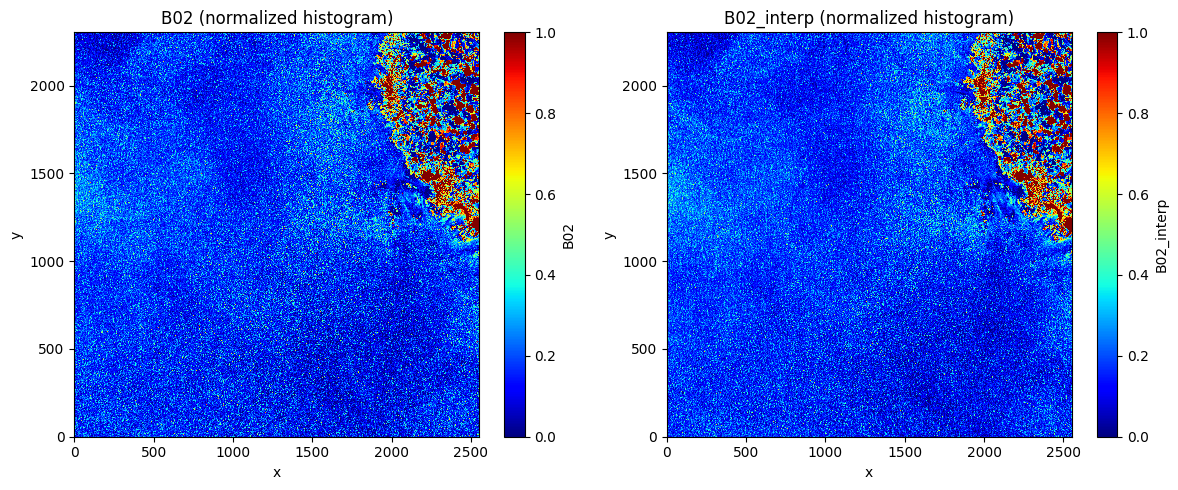

In [7]:
# Apply normalization
norm_b02 = normalize_histogram(ds.B02)
norm_b02_interp = normalize_histogram(ds.B02_interp)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
norm_b02.plot(ax=axes[0], cmap="jet")
axes[0].set_title("B02 (normalized histogram)")

norm_b02_interp.plot(ax=axes[1], cmap="jet")
axes[1].set_title("B02_interp (normalized histogram)")

plt.tight_layout()

# Reprojection on a 40m grid

In [ ]:
# Define parameters for a regular geographic grid
Earth_radius_eq = 6378137  # Earth's equatorial radius (in meters)
step = 40                  # Desired grid spacing (300 m between grid points)
size = 512                 # Number of grid points along each dimension (total grid size = size x size)

# Compute the central longitude and latitude of the dataset as the grid center
lon_center = np.median(ds.longitude.values.flatten())
lat_center = np.median(ds.latitude.values.flatten())

# Convert grid step (in meters) to radians, to use on a spherical Earth
dlat = np.rad2deg(step / Earth_radius_eq)                                   # Grid spacing in radians
dlon = np.rad2deg((step / Earth_radius_eq)/np.cos(np.deg2rad(lat_center)))  # Grid spacing in radians

# Construct longitude and latitude arrays for the grid
# Longitude array is repeated to form a full grid of size x size points
lon = np.tile(lon_center + (np.arange(size) - size // 2) * dlat, size)

# Latitude array is tiled to align with the longitude array, forming the same grid size
lat = np.repeat(lat_center + (np.arange(size) - size // 2) * dlon, size)

# Correct the longitude values for distortion due to latitude differences from the central latitude
lon = lon_center + (lon - lon_center) * np.cos(np.deg2rad(lat_center)) / np.cos(np.deg2rad(lat))

# Finally, recompute the HEALPix indices using corrected lon, lat arrays
hidx = hp.ang2pix(2**level,
                  lon,
                  lat,
                  lonlat=True,
                  nest=True)

In [32]:
# Define a range of HEALPix indices ("beg" to "ed") covering all relevant points
beg = np.min([h.min(), hidx.min()])
ed = np.max([h.max(), hidx.max()])

#This method consider that you can store all healpix indexes that are common between the input and the regrided data
print(f'Used an index storage of {ed-beg} values [{int((ed-beg)*8/(1024*1024))}MB]')

# Initialize an indexing array ("total_idx") to map all HEALPix pixels in the range [beg, ed]
# Initially set all entries to -1 (indicating no mapping yet)
total_idx = -np.ones([ed - beg + 1], dtype='int')

# Fill "total_idx" with indices corresponding to the actual pixels from array "h"
total_idx[h - beg] = np.arange(h.shape[0])

# Use "total_idx" to find indices ("l_idx") corresponding to each point in "hidx"
# This effectively links the original grid points to their corresponding pixels
l_idx = total_idx[hidx - beg]

# Generate a mask array identifying valid indices (pixels that exist in original data)
mask = np.where(l_idx != -1)[0]

# Initialize the output regridded B02 array with NaNs
regrid_b02 = np.full((size * size), np.nan)

# Fill the regridded array with valid values of image_b02 at positions indicated by mask
regrid_b02[mask] = image_b02[l_idx[mask]]

# Reshape the 1D array to a 2D grid (size x size)
regrid_b02 = regrid_b02.reshape(size, size)

Used an index storage of 75633475 values [577MB]


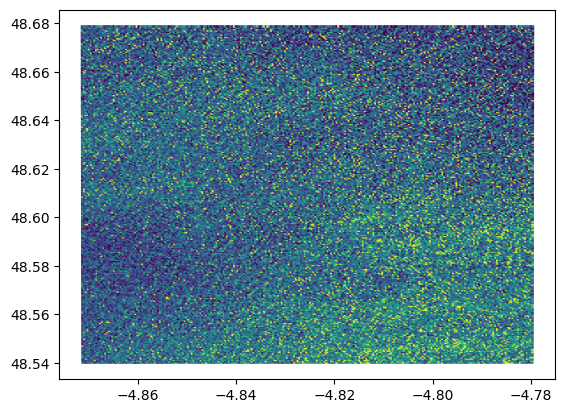

In [33]:
# Plot the normalized histogram version of regrid_b02 (to enhance visual contrast)
plt.scatter(lon,lat,c=normalize_histogram(regrid_b02,numpy_arr=True),s=1)